# LAB 1 : Show Explainability in Instrically explainable models. (Regression, Decision Trees, etc...)

## 1. Multiple Linear Regression

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Cellphone.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [ ]:
from sklearn.preprocessing import StandardScaler

y = df['Price']
X = df.drop(columns=['Product_id', 'Price'])

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

print(X.head())
print(y.head())

       Sale    weight  resoloution       ppi  cpu core  cpu freq  \
0 -0.396590 -0.382572    -0.006602  0.661751  1.289952 -0.255608   
1 -0.396590 -0.490564    -0.803808 -0.759303 -1.172684 -0.339231   
2 -0.396590 -0.652552    -0.338771 -0.171538 -0.351805 -0.506479   
3 -0.395942 -0.560759    -0.803808 -0.759303 -1.172684 -0.339231   
4 -0.395942 -0.490564    -0.803808 -0.759303 -1.172684 -0.339231   

   internal mem       ram   RearCam  Front_Cam   battery  thickness  
0     -0.296070  0.495385  0.425444   0.807868 -0.170327  -0.696211  
1     -0.713968 -0.750857 -1.172970  -1.040327 -0.838100   0.447564  
2     -0.574669 -0.439297  0.425444   0.114795 -0.617955  -0.604709  
3     -0.713968 -1.054940 -1.172970  -1.040327 -1.058245   0.950825  
4     -0.713968 -0.750857 -1.172970  -1.040327 -0.838100   0.447564  
0    2357
1    1749
2    1916
3    1315
4    1749
Name: Price, dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

LinearRegression()

[ -35.07100445  -35.15399368 -116.79590227  135.17584871  131.51980208
   78.86027465  179.46774186  149.57472244   31.09086175   38.82013625
  171.55558953 -161.06491518]


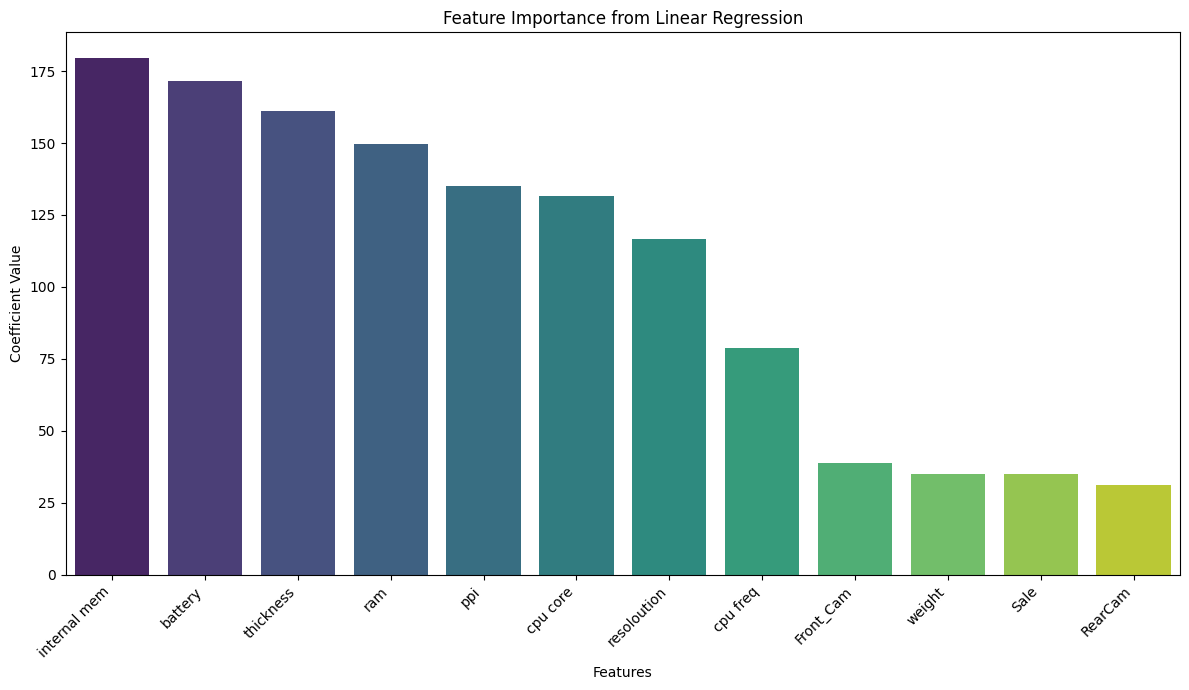

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_names = X.columns
coefficients = model.coef_
print(coefficients)
coefficients = abs(model.coef_)

feature_importance = pd.Series(coefficients, index=feature_names)

feature_importance_sorted = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_sorted.index, y=feature_importance_sorted.values, hue=feature_importance_sorted.index, palette='viridis', legend=False)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Feature Importance from Linear Regression')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Decision Trees

In [ ]:
import pandas as pd
df = pd.read_csv('/content/MBA.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [ ]:
df_processed = df.dropna(subset=['admission']).copy()

In [ ]:
categorical_cols = df_processed.select_dtypes(include=['object', 'bool']).columns.tolist()
if 'application_id' in categorical_cols:
    categorical_cols.remove('application_id')
if 'admission' in categorical_cols:
    categorical_cols.remove('admission')

print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, dummy_na=True, drop_first=False)
print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)

X = df_encoded.drop(columns=['application_id', 'admission'])
y = df_encoded['admission']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Categorical columns to encode: ['gender', 'international', 'major', 'race', 'work_industry']
Shape of DataFrame after one-hot encoding: (1000, 36)
Shape of X: (1000, 34)
Shape of y: (1000,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)

dtc.fit(X, y)

DecisionTreeClassifier(random_state=42)

In [ ]:
import pandas as pd

importances = dtc.feature_importances_

feature_importances = pd.Series(importances, index=X.columns)

print(feature_importances.head())

gpa              0.200411
gmat             0.175419
work_exp         0.118106
gender_Female    0.008889
gender_Male      0.014196
dtype: float64


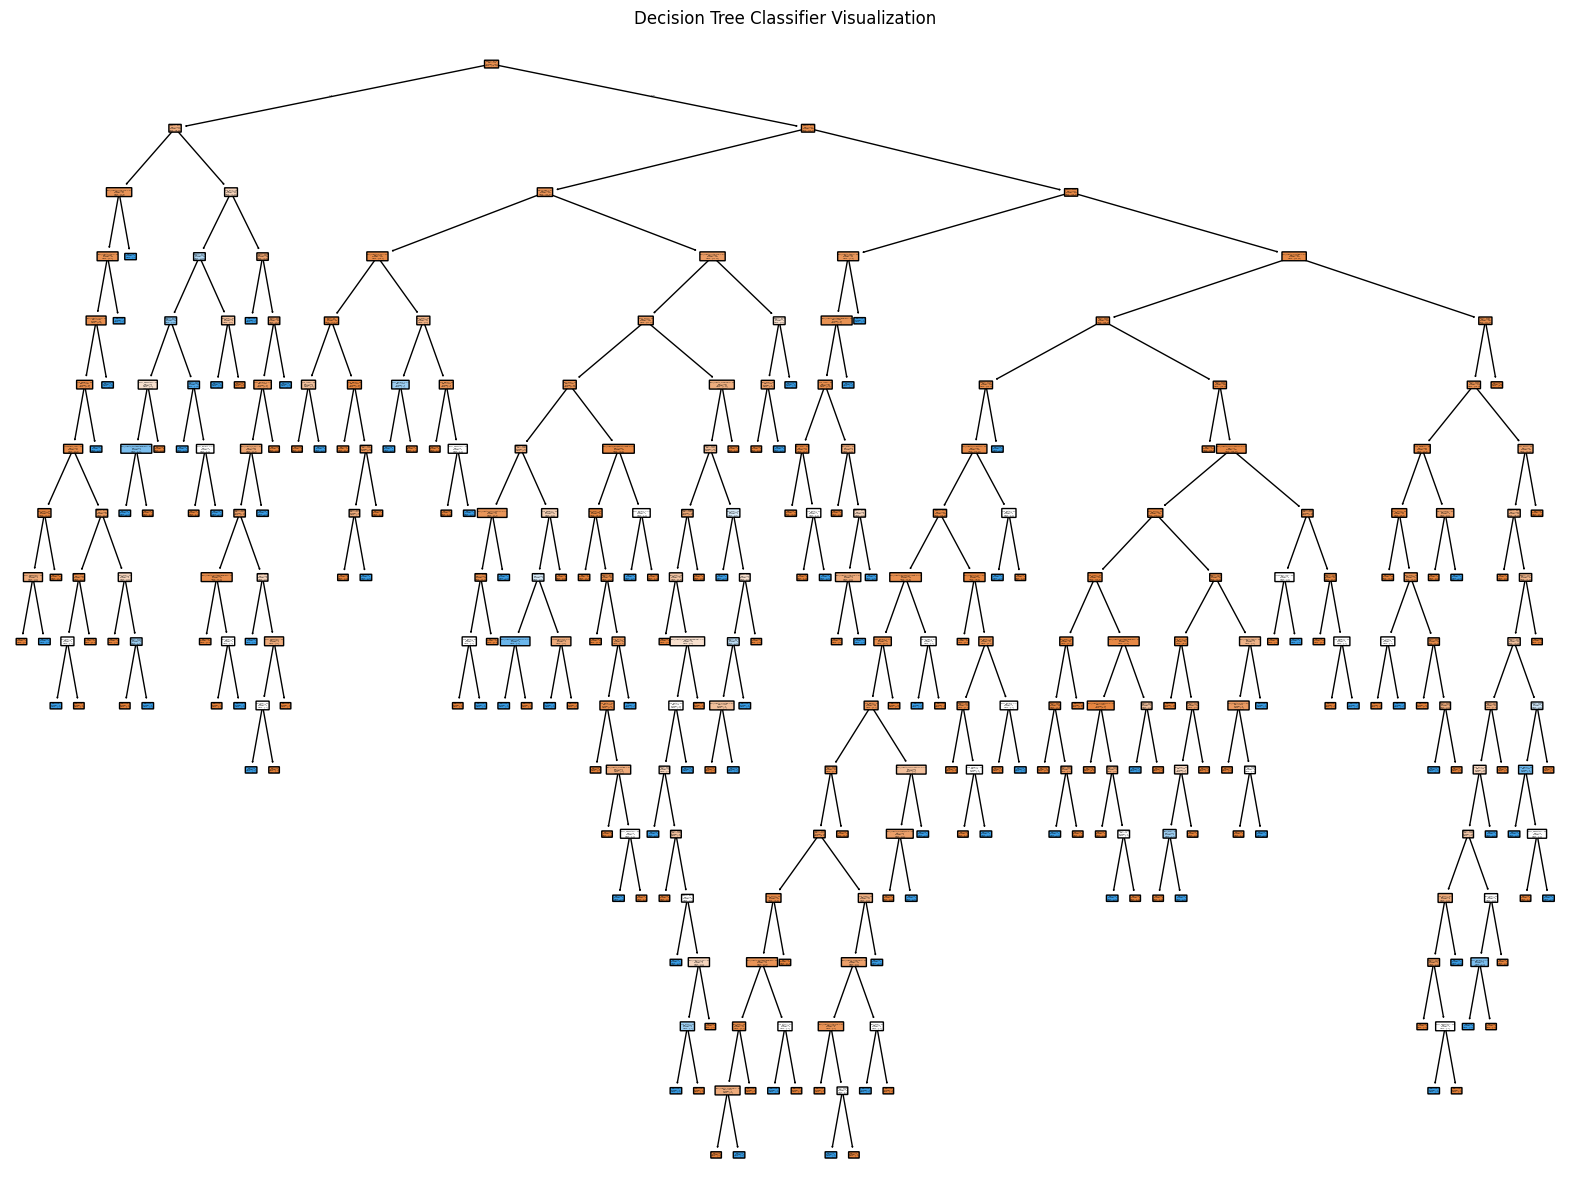

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15))
plot_tree(dtc, feature_names=X.columns.tolist(), class_names=dtc.classes_.tolist(), filled=True, rounded=True)
plt.title('Decision Tree Classifier Visualization')
plt.show()

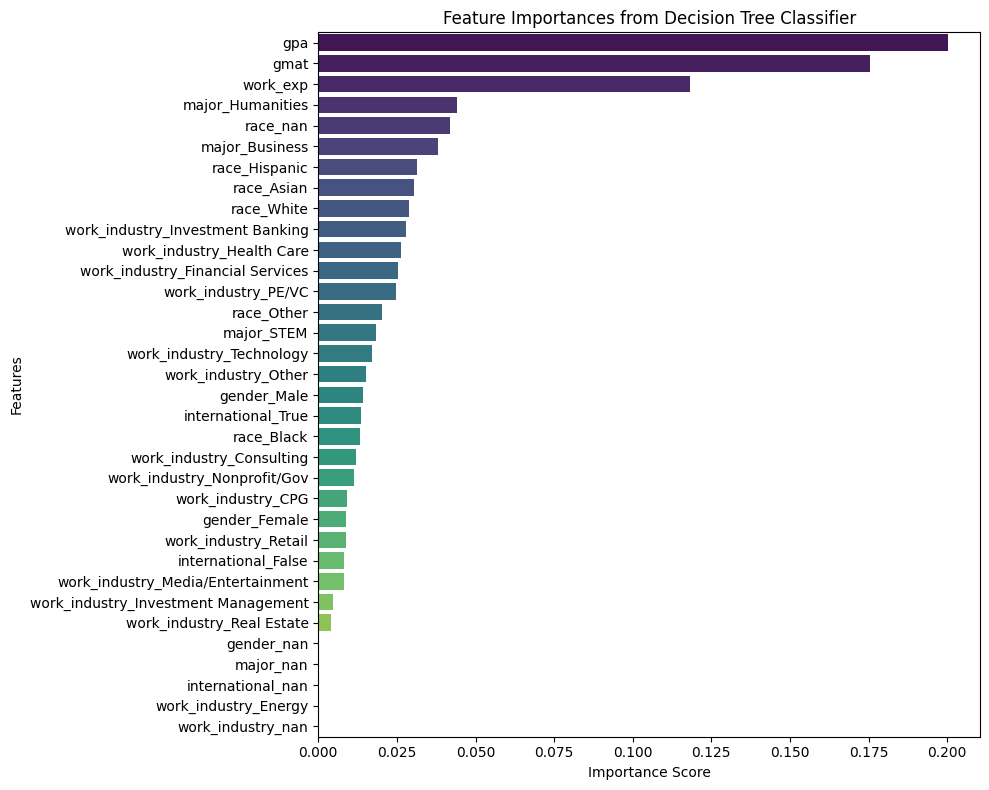

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sorted_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, hue=sorted_importances.index, palette='viridis', legend=False)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importances from Decision Tree Classifier')

plt.tight_layout()

plt.show()

## Random Forest using SHAP

In [ ]:
import pandas as pd
df = pd.read_csv('/content/winequality-red.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

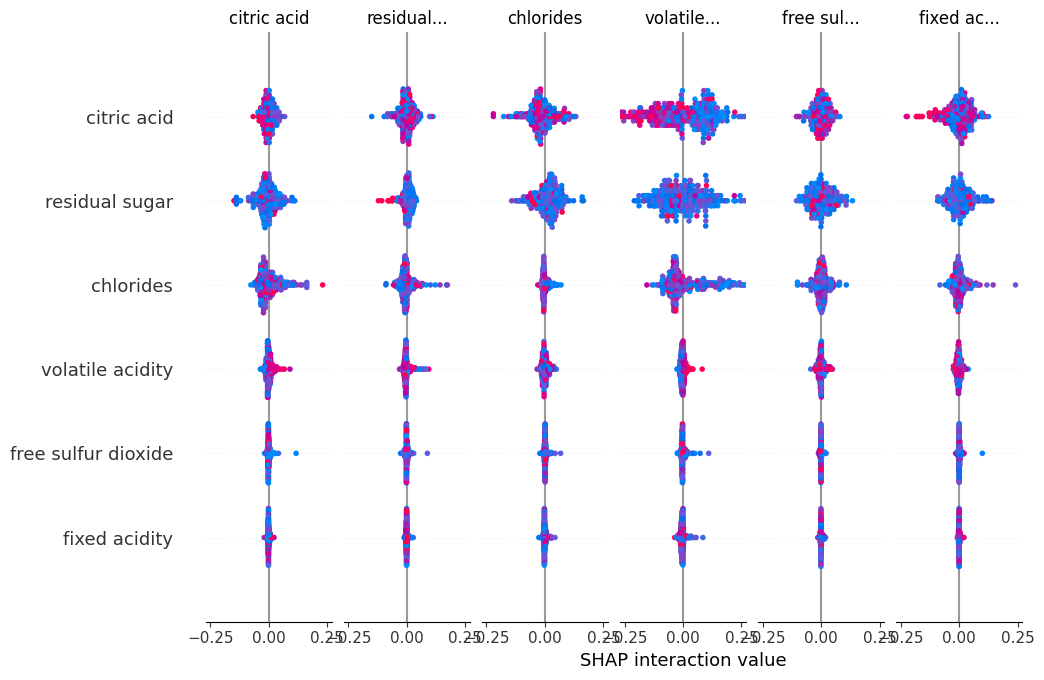

In [ ]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test)
plt.show()

The SHAP interaction plot shows how pairs of features jointly influence the model’s predictions. Most interaction values are very close to zero, which indicates that the model mainly relies on the individual effect of each feature rather than strong interactions between them. There are some moderate interactions involving citric acid, residual sugar, chlorides, and volatile acidity, suggesting that the impact of one of these variables may slightly change depending on the value of another. For example, the effect of citric acid on prediction may vary when volatile acidity or residual sugar changes. However, features like free sulfur dioxide and fixed acidity show very small interaction effects, meaning they mostly contribute independently to the prediction. Overall, the model behaves largely in an additive manner, with only limited pairwise feature interactions influencing the output.